In [1]:
import pandas as pd
from glob import glob
import numpy as np
from numba import njit

from matplotlib import font_manager
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter1d
import itertools
import regseq2

from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
from matplotlib import collections  as mc
import matplotlib.colors as mcolors

regseq2.viz.matplotlib_style()
regseq2.viz.my_color_dict

from denovo_scanner import build_wt_dict, run_scan, save_outputs, load_df_map

weight = 'regular'
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Lato"],

    "font.weight": weight,        # ticks, text
    "axes.labelweight": weight,   # axis labels
    "axes.titleweight": weight,   # titles
})


In [2]:
df_gc = pd.read_csv("../../data/metadata/growth_conditions_short.csv", delimiter=";")
print(df_gc.tail(5))

    Index             Condition  \
34     37         low phosphate   
35     38  copper sulfate (2mM)   
36     39               acetate   
37     40               nitrate   
38     41   anaerobic + nitrate   

                                          Description  \
34  M9 Minimal Media with 0.5% Glucose to steady s...   
35  M9 Minimal Media with 0.5% Glucose to steady s...   
36          M9 Minimal Media with 0.5% Sodium Acetate   
37  M9 Minimal Media with 0.5% Glucose with 80mM P...   
38  M9 Minimal Media with 0.5% Glucose grown compl...   

                          Group  
34  Nutrient–mineral limitation  
35      Metal & membrane stress  
36                Carbon‐source  
37       Osmotic & ionic stress  
38                    Anaerobic  


In [ ]:
# ----------------------------
# Global figure + font settings
# ----------------------------
FIG_WIDTH = 7.0
FIG_HEIGHT = 3.0

mpl.rcParams.update({
    # Figure geometry
    "figure.figsize": (FIG_WIDTH, FIG_HEIGHT),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Fonts
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Lines / markers
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes styling
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # Mathtext / fonts (no external LaTeX dependency)
    #"mathtext.fontset": "stix",
    #"font.family": "STIXGeneral",
})



In [4]:
df_wt = pd.read_csv("../../data/metadata/wt_sequences.csv")[['promoter_seq', 'promoter']]
wt_dict = dict(zip(df_wt['promoter'].values, df_wt['promoter_seq'].values))
df_wt

,promoter_seq,promoter
0,TTTCATCTTTTGTCAACCATTCACAGCGCAAATATACGCCTTTTTT...,rspAp
1,TCCACATTGATTATTTGCACGGCGTCACACTTTGCTATGCCATAGC...,araBp
2,GTGTTGCACCTCCCCAGAGAGCGGCGGATAATGCTGCGAAAAGAAG...,znuCp
3,CCAGTTTCATCATTCCATTTTATTTTGCGAGCGAGCGCACACTTGT...,xylAp
4,AATTGCGCAACAAAAGTAAGATCTCGGTCATAAATCAAGAAATAAA...,xylFp
...,...,...
112,TGGTGCTGGTTATCAGCACTGAAGGCGACACCGACGTGAAGCACTA...,ygeY_predicted
113,CGCTGGACGAAATCCGCGCCCTGCCTGCAGTACAGAAAGCTAACGC...,hyuA_predicted
114,TCGGACATGTTTGAAGAGATGAAATTTGCCTTCTTTAAACATCGCG...,ygfM_xdhD_predicted
115,AGTGCCAGTTTTTGCGAGGAAGGGGAGTTAGAGACAGGAATTGCGG...,ygfS_ygfT_predicted


In [5]:
# List growth condition indices from the DNA barcode files (each ind = one sample / condition).
files = np.hstack([glob("../../data/extracted_barcodes/*DNA*.txt")])
inds = np.sort([x.split('/')[-1].split('_')[0] for x in files])

# Drop samples that failed QC 
bad_inds = ['14-3', '15-1', '19-1', '22-1', '25-2', '38-2', '4-1', '31-2', '20-2', '13-2', '26-1', '26-2']
inds = [ind for ind in inds if ind not in bad_inds]


In [ ]:
# Only the primitives shared by every notebook live in the package
# (src/regseq2/analysis.py): loading counts and computing the real MI footprint.
from regseq2 import get_counts, compute_MI_from_counts, compute_MI

# Scrambling / null-distribution functions are still being developed here, not
# yet part of the shared package — defined below. They reuse
# `_prepare_promoter_arrays`/`_mi_footprint` from regseq2.analysis (rather than
# reimplementing the MI math a second time) so the null footprint is guaranteed
# to use the exact same computation as `compute_MI_from_counts`.
from regseq2.analysis import _prepare_promoter_arrays, _mi_footprint, _EXCLUDED_PROMOTERS


In [ ]:
def scramble_counts(df_counts, replace=False, random_state=None):
    """Randomly reassign (ct_0, ct_1) count pairs across sequences within each promoter.

    Breaks the association between a barcode's mutated sequence and its measured
    counts while keeping each barcode's own ct_0/ct_1 pair intact together, giving
    a null/background dataset for MI computation.

    Parameters
    ----------
    df_counts : pandas.DataFrame
        Output of `get_counts`, with (at least) columns 'name', 'ct_0', 'ct_1'.
    replace : bool
        If False (default), shuffle count pairs without replacement (a permutation,
        so every original pair is used exactly once per promoter). If True, sample
        count pairs with replacement (a bootstrap resample).
    random_state : int | np.random.Generator | None
        Seed or generator for reproducibility.

    Returns
    -------
    pandas.DataFrame
        Copy of `df_counts` with 'ct_0'/'ct_1' scrambled within each promoter group;
        all other columns (including the sequence) are left untouched.
    """
    rng = np.random.default_rng(random_state)
    df_scrambled = df_counts.copy()

    for promoter, gdf in df_counts.groupby("name"):
        idx = gdf.index.values
        sampled = rng.choice(idx, size=len(idx), replace=replace)
        df_scrambled.loc[idx, "ct_0"] = df_counts.loc[sampled, "ct_0"].values
        df_scrambled.loc[idx, "ct_1"] = df_counts.loc[sampled, "ct_1"].values

    return df_scrambled


def get_counts_scrambled(ind, promoter=None, replace=False, random_state=None):
    """Load DNA + RNA barcode counts for sample `ind` via `get_counts`, then scramble
    the ct_0/ct_1 pairs within each promoter via `scramble_counts`.

    See `get_counts` and `scramble_counts` for parameter documentation.
    """
    df_counts = get_counts(ind, promoter)
    return scramble_counts(df_counts, replace=replace, random_state=random_state)


In [ ]:
def compute_MI_scrambled(
    ind,
    promoter_list=None,
    *,
    replace=False,
    random_state=None,
    a=0.0,
    **kwargs,
):
    """Null information footprint: same as `compute_MI`, but computed from counts
    whose ct_0/ct_1 pairs have been scrambled across sequences within each promoter
    (via `get_counts_scrambled`), destroying any real sequence↔expression association.

    Comparing this against `compute_MI(ind, promoter_list, **kwargs)` shows how much
    of the raw MI footprint is signal versus what scrambled (null) data produces by
    chance, given the same read-depth/transform settings.

    Parameters
    ----------
    ind : str
        Growth condition index (matches DNA/RNA barcode files).
    promoter_list : str | list[str] | None
        Restrict to one or more promoters; None → all promoters in `df_map`.
    replace : bool
        Passed to `scramble_counts`: False (default) shuffles ct_0/ct_1 pairs without
        replacement (permutation); True resamples them with replacement (bootstrap).
    random_state : int | np.random.Generator | None
        Seed or generator for reproducibility.
    a : float
        Background MI subtracted as `a / N` per position, clipped at 0 (see
        `compute_MI_from_counts`).
    **kwargs
        Forwarded to `compute_MI_from_counts` (transform, barcode_equal,
        require_both_counts, positions, normalize_by_entropy).

    Returns
    -------
    pandas.DataFrame with one row per (promoter, position), same schema as `compute_MI`.
    """
    df_scrambled = get_counts_scrambled(
        ind, promoter_list, replace=replace, random_state=random_state
    )
    return compute_MI_from_counts(df_scrambled, ind=ind, a=a, **kwargs)


In [ ]:
def compute_MI_null_percentile(
    ind,
    promoter,
    n=100,
    *,
    replace=False,
    random_state=None,
    a=0.0,
    smooth=False,
    sigma=2,
    transform="sqrt",
    barcode_equal=False,
    require_both_counts=False,
):
    """Percentile of the real information footprint relative to a scrambled null.

    Loads counts for `ind`/`promoter` once and precomputes the WT-match matrix,
    its complement, and the transformed DNA/RNA weight vectors once
    (`_prepare_promoter_arrays`) — the expensive, per-barcode setup that's fixed
    across every scramble. A scramble is then nothing more than a random
    permutation (`replace=False`) or an integer resample with replacement
    (`replace=True`) of which weight-vector entry lines up with which barcode, fed
    straight into the MI computation (`_mi_footprint`); no file I/O, no
    DataFrame rebuilding, and no re-deriving `mismatch` happens inside the
    `n`-draw loop.

    For each position, reports what percentile the real MI value falls at relative
    to the `n` null values at that position.

    NOTE on `a`: the background subtraction `a / N` (clipped at 0) is applied to
    BOTH the real and every null footprint. If `a` is large relative to this
    promoter/sample's own scramble-to-scramble noise, most or all null draws can
    collapse to exactly 0 at a position; since the percentile below uses `<=`,
    any real value (including 0) then ties-or-beats the whole null distribution
    there, pushing percentiles toward 100 almost everywhere. That's an artifact
    of comparing two already-clipped distributions, not a sign the real footprint
    is significant everywhere — pass `a=0` to compare raw (unsubtracted) MI values
    if that's not what you want.

    Parameters
    ----------
    ind : str
        Growth condition index (matches DNA/RNA barcode files).
    promoter : str
        A single promoter name. Percentiles are computed along that promoter's
        position axis, so mixing promoters of different lengths isn't supported.
    n : int
        Number of scrambled/null footprints to draw.
    replace : bool
        False (default): each scramble is a random permutation of barcodes (every
        barcode's counts used exactly once). True: each scramble resamples
        barcodes with replacement (bootstrap).
    random_state : int | np.random.Generator | None
        Seed or generator for the scrambles. The same generator is advanced across
        the `n` draws, so they differ from each other but are reproducible from a
        given seed.
    a : float
        Background MI subtracted (`a / N`, clipped at 0) from both the real and
        null footprints; see the note above and `_mi_footprint`.
    smooth : bool
        If True, apply `gaussian_filter1d(x, sigma)` to the real footprint and each
        null footprint before computing percentiles.
    sigma : float
        Gaussian smoothing bandwidth used when `smooth=True`.
    transform, barcode_equal, require_both_counts
        Forwarded to `_prepare_promoter_arrays` (see `compute_MI_from_counts`).

    Returns
    -------
    percentiles : list[float]
        One percentile (0-100) per position: the percentage of the `n` null MI
        values at that position that are <= the real MI value.
    null_mi : numpy.ndarray, shape (n, L)
        The raw null-footprint MI values drawn for each of the `n` scrambles, for
        inspecting/plotting the null distribution itself.
    """
    if promoter in _EXCLUDED_PROMOTERS:
        raise ValueError(f"{promoter!r} is excluded from MI computation")

    df_counts = get_counts(ind, promoter)
    gdf = df_counts[df_counts["name"] == promoter]
    is_match, x, y, _ = _prepare_promoter_arrays(
        gdf, promoter,
        transform=transform, barcode_equal=barcode_equal, require_both_counts=require_both_counts,
    )
    N, L = is_match.shape
    mismatch = 1.0 - is_match  # fixed across all scrambles; computed once

    real_result = _mi_footprint(is_match, x, y, mismatch=mismatch, a=a)
    if real_result is None:
        raise ValueError(f"no usable reads for promoter {promoter!r} in sample {ind!r}")
    real_mi = real_result[0]

    rng = np.random.default_rng(random_state)
    null_mi = np.empty((n, L))
    for i in range(n):
        perm = rng.integers(0, N, size=N) if replace else rng.permutation(N)
        null_mi[i] = _mi_footprint(is_match, x[perm], y[perm], mismatch=mismatch, a=a)[0]

    if smooth:
        real_mi = gaussian_filter1d(real_mi, sigma)
        null_mi = np.vstack([gaussian_filter1d(row, sigma) for row in null_mi])

    percentiles = (null_mi <= real_mi[None, :]).mean(axis=0) * 100
    return percentiles.tolist(), null_mi


In [11]:
a = 8.13907748

In [12]:
compute_MI('3-1', 'araBp', a=a)

,promoter,pos,mut_info,N,N_reads,N_seqs,ind,transform,barcode_equal,require_both_counts,a
0,araBp,0,0.000000,6131.0,9785.943447,1647.0,3-1,sqrt,False,False,8.139077
1,araBp,1,0.000000,6131.0,9785.943447,1647.0,3-1,sqrt,False,False,8.139077
2,araBp,2,0.000000,6131.0,9785.943447,1647.0,3-1,sqrt,False,False,8.139077
3,araBp,3,0.001726,6131.0,9785.943447,1647.0,3-1,sqrt,False,False,8.139077
4,araBp,4,0.000000,6131.0,9785.943447,1647.0,3-1,sqrt,False,False,8.139077
...,...,...,...,...,...,...,...,...,...,...,...
155,araBp,155,0.000000,6131.0,9785.943447,1647.0,3-1,sqrt,False,False,8.139077
156,araBp,156,0.000000,6131.0,9785.943447,1647.0,3-1,sqrt,False,False,8.139077
157,araBp,157,0.000000,6131.0,9785.943447,1647.0,3-1,sqrt,False,False,8.139077
158,araBp,158,0.000000,6131.0,9785.943447,1647.0,3-1,sqrt,False,False,8.139077


<BarContainer object of 160 artists>

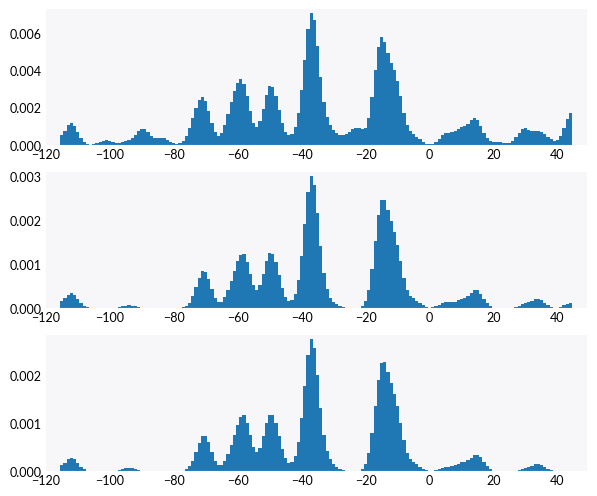

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(FIG_WIDTH, 6))


x1 = compute_MI('3-1', 'araBp',transform='raw', a=a)['mut_info'].values
x2 = compute_MI('3-1', 'araBp',transform='sqrt', a=a)['mut_info'].values
x3 = compute_MI('3-1', 'araBp',transform='log1p', a=a)['mut_info'].values

ax[0].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x1, 2), width=1)
ax[1].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x2, 2), width=1)
ax[2].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x3, 2), width=1)

Text(0.5, 1.0, 'araB')

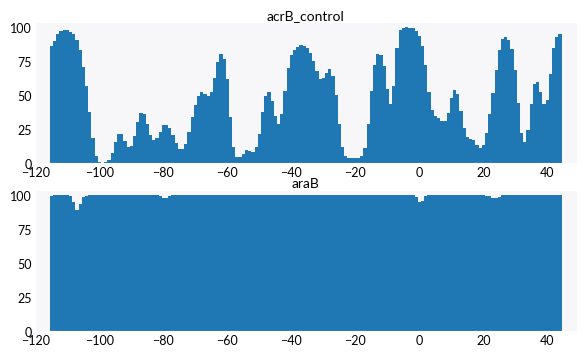

In [ ]:
x, x_null = compute_MI_null_percentile('3-1', 'acrBp', transform='sqrt', a=0, n=10000, replace=False)

fig, ax = plt.subplots(2, 1, figsize=(FIG_WIDTH, 4))
ax[0].bar(np.arange(-115, 45), x, width=1)
ax[0].set_title('acrB_control')

x, x_null = compute_MI_null_percentile('3-1', 'araBp', transform='sqrt', a=0, n=10000, replace=False)
ax[1].bar(np.arange(-115, 45), x, width=1)
ax[1].set_title('araB')


Text(0.5, 1.0, 'position > 0.9999')

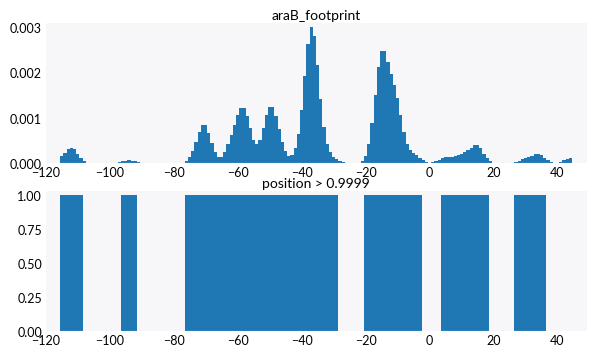

In [49]:
prom = "araBp"
ind = '3-1'

x_data = compute_MI(ind, prom,transform='sqrt', a=a)['mut_info'].values

fig, ax = plt.subplots(2, 1, figsize=(FIG_WIDTH, 4))
ax[0].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x_data, 2), width=1)
ax[0].set_title('araB_footprint')

x, x_null = compute_MI_null_percentile(ind, prom, transform='sqrt', a=a, n=10000, replace=False)
x_filter = np.array(x) > 99.99
ax[1].bar(np.arange(-115, 45), x_filter, width=1)
ax[1].set_title('position > 0.9999')


Text(0.5, 1.0, 'position > 0.9999')

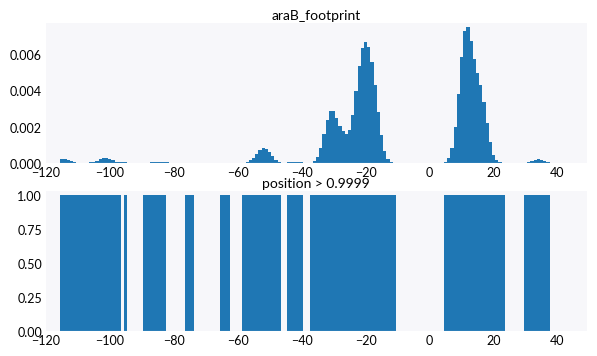

In [50]:
prom = "yjbJ_predicted"
ind = '36-1'

x_data = compute_MI(ind, prom,transform='sqrt', a=a)['mut_info'].values

fig, ax = plt.subplots(2, 1, figsize=(FIG_WIDTH, 4))
ax[0].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x_data, 2), width=1)
ax[0].set_title('yjbJ_footprint')

x, x_null = compute_MI_null_percentile(ind, prom, transform='sqrt', a=a, n=10000, replace=False)
x_filter = np.array(x) > 99.99
ax[1].bar(np.arange(-115, 45), x_filter, width=1)
ax[1].set_title('position > 0.9999')


Text(0.5, 1.0, 'position > 0.9999')

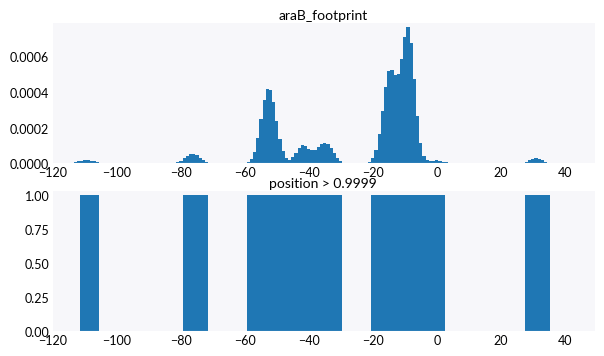

In [51]:
prom = "cpxRp2"
ind = '29-1'

x_data = compute_MI(ind, prom,transform='sqrt', a=a)['mut_info'].values

fig, ax = plt.subplots(2, 1, figsize=(FIG_WIDTH, 4))
ax[0].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x_data, 2), width=1)
ax[0].set_title('cpxRp2_footprint')

x, x_null = compute_MI_null_percentile(ind, prom, transform='sqrt', a=a, n=10000, replace=False)
x_filter = np.array(x) > 99.99
ax[1].bar(np.arange(-115, 45), x_filter, width=1)
ax[1].set_title('position > 0.9999')


Text(0.5, 1.0, 'position > 0.9999')

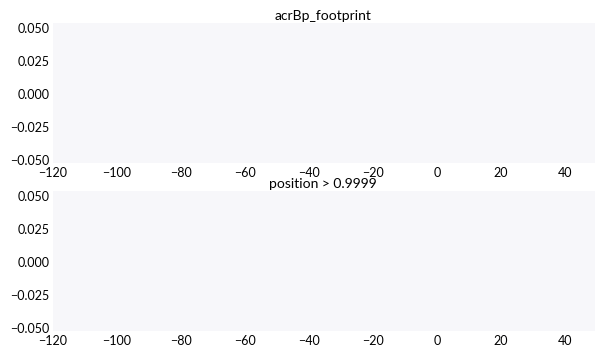

In [52]:
prom = "acrBp"
ind = '1-1'

x_data = compute_MI(ind, prom,transform='sqrt', a=a)['mut_info'].values

fig, ax = plt.subplots(2, 1, figsize=(FIG_WIDTH, 4))
ax[0].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x_data, 2), width=1)
ax[0].set_title('acrBp_footprint')

x, x_null = compute_MI_null_percentile(ind, prom, transform='sqrt', a=a, n=10000, replace=False)
x_filter = np.array(x) > 99.99
ax[1].bar(np.arange(-115, 45), x_filter, width=1)
ax[1].set_title('position > 0.9999')


In [39]:
x = compute_MI_null_percentile('1-1', 'acrBp', transform='sqrt', a=0, n=1000, smooth=False)
x1 = compute_MI('3-1', 'araBp',transform='raw', a=a)['mut_info'].values
x2 = compute_MI('3-1', 'araBp',transform='sqrt', a=a)['mut_info'].values
x3 = compute_MI('3-1', 'araBp',transform='log1p', a=a)['mut_info'].values

fig, ax = plt.subplots(1, 2, figsize=(FIG_WIDTH, 4))

ax[0].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x1, 2), width=1)
ax[1].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x2, 2), width=1)


ax.bar(np.arange(-115, 45), x, width=1)

KeyboardInterrupt: 

In [ ]:
compute_MI_null_percentile('3-1', 'araBp',transform='sqrt', a=0)

In [15]:
compute_MI('3-1', 'araBp',transform='sqrt', a=a)['mut_info'].values

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.72617409e-03,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.28572261e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.27663056e-04, 1.18575262e-03,
       2.43219175e-04, 3.19200738e-03, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.33145882e-03, 7.71813753e-04, 0.00000000e+00,
      